# GeoDataFrame Cleaning: India Administrative Areas

In [1]:
import geopandas as gpd
from unidecode import unidecode
import matplotlib.pyplot as plt

from adjustText import adjust_text
import colorcet as cc
import numpy as np

## States and Union Territories
### Dataset Inspection

In [2]:
!ls ../data

india_admin_areas.geojson  nederland_admin_areas.gpkg	sources
india_districts.geojson    nederland_pop_centres.gpkg
india_states.geojson	   nederland_pop_stats.feather


In [3]:
data_folder = '../data'
states = gpd.read_file(f'{data_folder}/india_states.geojson')

states.shape

(36, 6)

In [4]:
print(states.crs)

EPSG:4326


In [5]:
states = states.to_crs('EPSG:7755')
states.head(1)

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Puducherry,IN-PY,1811400B81659894240990,IND,ADM1,"MULTIPOLYGON (((3511510.758 2663249.333, 35114..."


### Dropping Unwanted Columns

In [6]:
states = states[['shapeName', 'geometry']]
states = states.rename(columns={'shapeName': 'name'})

states.head(1)

,name,geometry
0,Puducherry,"MULTIPOLYGON (((3511510.758 2663249.333, 35114..."


In [7]:
for i in states['name']:
    print(i)

Puducherry
Mahārāshtra
Nāgāland
Lakshadweep
Uttar Pradesh
Tamil Nādu
Chhattīsgarh
Gujarāt
Delhi
Sikkim
Tripura
West Bengal
Odisha
Bihār
Ladākh
Rājasthān
Telangāna
Andhra Pradesh
Mizoram
Arunāchal Pradesh
Meghālaya
Jhārkhand
Assam
Manipur
Karnātaka
Uttarākhand
Dādra and Nagar Haveli and Damān and Diu
Madhya Pradesh
Goa
Kerala
Chandīgarh
Andaman and Nicobar Islands
Himāchal Pradesh
Jammu and Kashmīr
Punjab
Haryāna


### Removing Diacritics

In [8]:
states['name'] = states['name'].apply(unidecode)

for i in states['name']:
    print(i)

Puducherry
Maharashtra
Nagaland
Lakshadweep
Uttar Pradesh
Tamil Nadu
Chhattisgarh
Gujarat
Delhi
Sikkim
Tripura
West Bengal
Odisha
Bihar
Ladakh
Rajasthan
Telangana
Andhra Pradesh
Mizoram
Arunachal Pradesh
Meghalaya
Jharkhand
Assam
Manipur
Karnataka
Uttarakhand
Dadra and Nagar Haveli and Daman and Diu
Madhya Pradesh
Goa
Kerala
Chandigarh
Andaman and Nicobar Islands
Himachal Pradesh
Jammu and Kashmir
Punjab
Haryana


### Visualising the GeoDataFrame

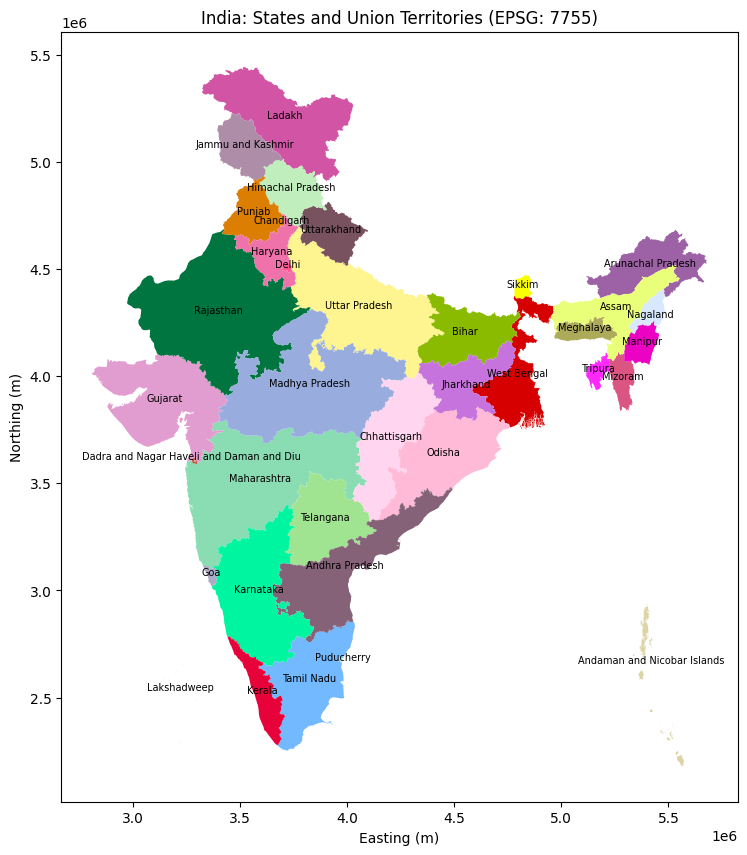

In [9]:
fig, ax = plt.subplots(figsize=(10,10))
states.plot(ax=ax, column='name', cmap=cc.cm.glasbey_light_r)

for row in states.itertuples():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    if row.name in ['Chandigarh', 'Jharkhand', 'Nagaland']:
        y -= 0.25 * 10**5
        
    ax.annotate(xy=(x,y), text=row.name, ha='center', fontsize=7)

ax.set_title('India: States and Union Territories (EPSG: 7755)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

### Exporting the Layer

In [10]:
states.to_file(f'{data_folder}/states.gpkg', driver='gpkg')

## Country 
### Layer Creation

In [11]:
india = states.union_all()

In [12]:
country_df = {
    'name': ['india'],
    'geometry': [india]
}
country = gpd.GeoDataFrame(country_df, crs='EPSG:7755')

country.shape

(1, 2)

In [13]:
country.head(1)

,name,geometry
0,india,"MULTIPOLYGON (((3698340.435 2258768.546, 36979..."


In [14]:
print(country.crs)

EPSG:7755


### Visualising the GeoDataFrame

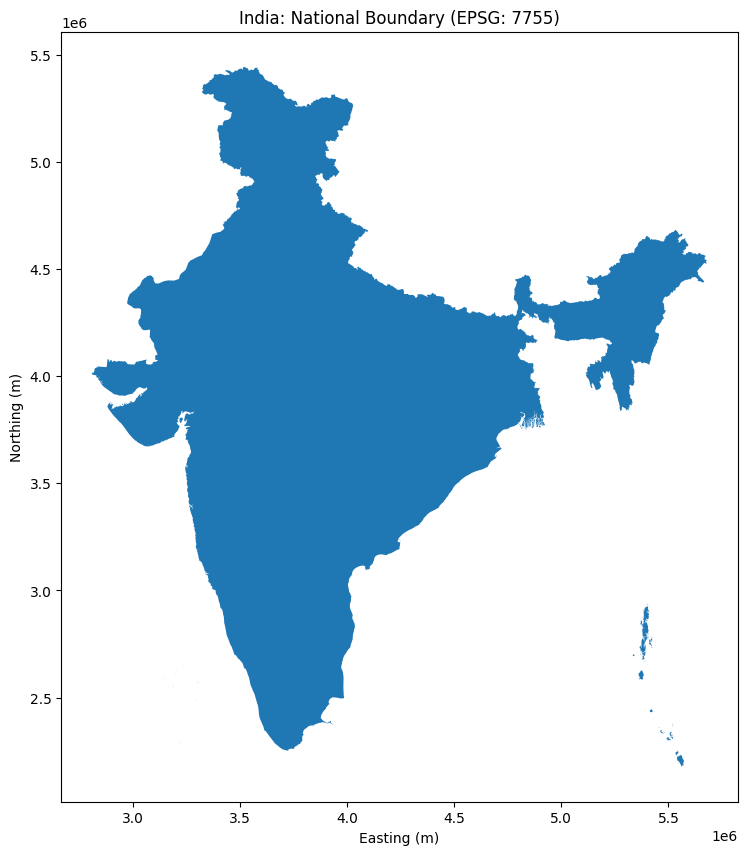

In [15]:
fig, ax = plt.subplots(figsize=(10,10))
country.plot(ax=ax)

ax.set_title('India: National Boundary (EPSG: 7755)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

### Exporting the Layer

In [16]:
country.to_file(f'{data_folder}/country.gpkg', driver='GPKG')

## Districts
### Dataset Inspection

In [17]:
districts = gpd.read_file(f'{data_folder}/india_districts.geojson')
districts.shape

(735, 6)

In [18]:
print(districts.crs)

EPSG:4326


In [19]:
districts = districts.to_crs('EPSG:7755')
districts.head(1)

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Ashoknagar,,76128533B75548370501185,IND,ADM2,"POLYGON ((3819099.29 4092681.764, 3818492.314 ..."


### Assigning State/ Union Territory to Each Distict

In [20]:
districts = districts.reset_index()

overlayed_gdf = gpd.overlay(states, districts, how='intersection')
overlayed_gdf['area'] = overlayed_gdf.area

overlayed_gdf = overlayed_gdf.sort_values('area').drop_duplicates('index', keep='last')
overlayed_gdf.shape

(735, 9)

In [21]:
overlayed_gdf['name'].count()

np.int64(735)

In [22]:
overlayed_gdf.head(1)

,name,index,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry,area
4,Puducherry,269,Mahe,,76128533B41246169049488,IND,ADM2,"MULTIPOLYGON (((3512802.096 2663022.908, 35127...",7.847807e+06


In [23]:
overlayed_gdf = overlayed_gdf[['shapeName', 'name', 'geometry']]
overlayed_gdf = overlayed_gdf.rename(columns={'name': 'state', 'shapeName': 'name'})
districts = overlayed_gdf

districts.shape

(735, 3)

In [24]:
districts.head(1)

,name,state,geometry
4,Mahe,Puducherry,"MULTIPOLYGON (((3512802.096 2663022.908, 35127..."


### Visualising the GeoDataFrame

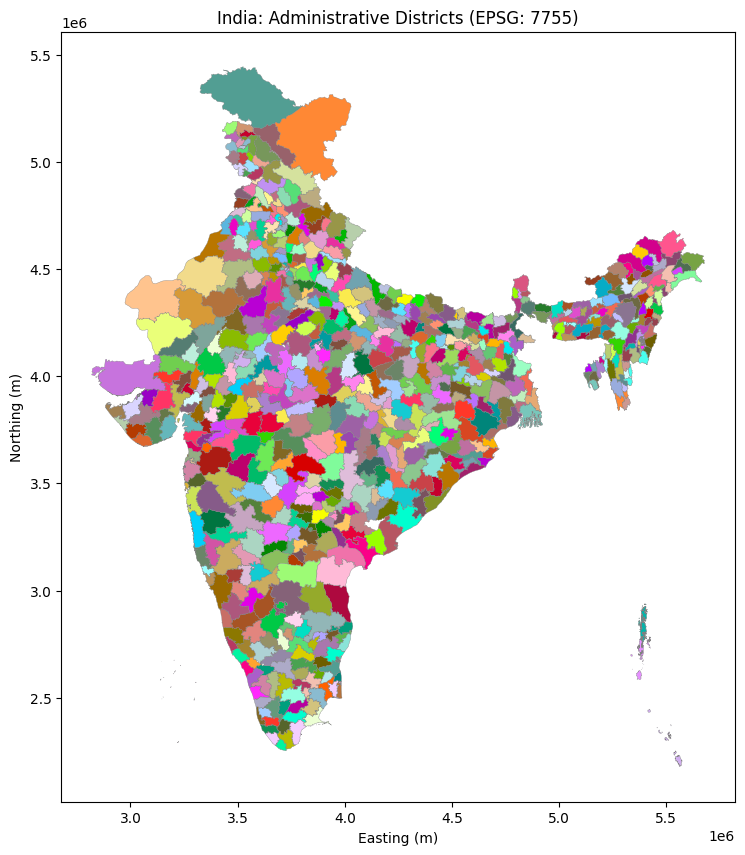

In [25]:
fig, ax = plt.subplots(figsize=(10,10))
districts.plot(ax=ax, column='name', cmap=cc.cm.glasbey_light_r, edgecolor='gray', linewidth=0.25)

ax.set_title('India: Administrative Districts (EPSG: 7755)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

### Exporting the Layer

In [26]:
districts.to_file(f'{data_folder}/districts.gpkg', driver='GPKG')

## Exporting all Layers to a GeoPackage

In [27]:
layers = ['country', 'states', 'districts']

In [28]:
for layer in layers:
    gdf = gpd.read_file(f'{data_folder}/{layer}.gpkg')
    gdf.to_file(f'{data_folder}/india_admin_areas_new.gpkg', driver='GPKG', layer=layer)

### Visualising the Layers

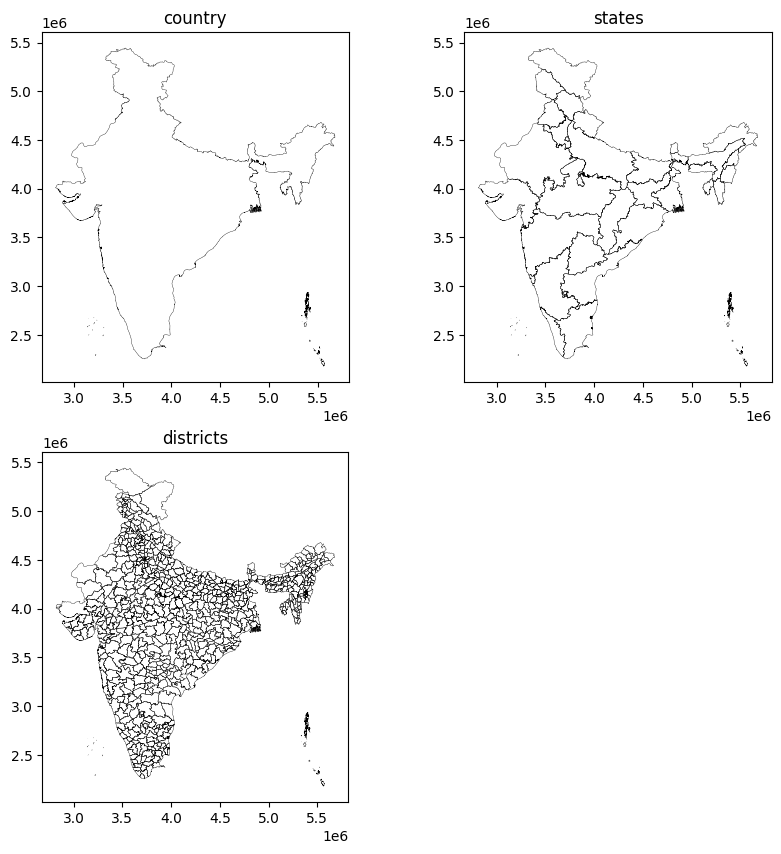

In [29]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
ax = axs.flatten()

for layer, i in zip(layers, range(3)):
    gdf = gpd.read_file(f'{data_folder}/india_admin_areas_new.gpkg', layer=layer)
    
    gdf.plot(ax=ax[i], color='none', linewidth=0.25)
    ax[i].set_title(layer)

fig.delaxes(ax[i+1])
plt.show() 